In [9]:
## IMPORTS AND SETUP
# Imports
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf
import datetime
import logging
import warnings
import wandb
import shutil
from PIL import Image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tqdm.notebook import tqdm
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from wandb.integration.keras import WandbMetricsLogger
from dotenv import load_dotenv
from tensorflow.keras.applications import VGG16
from collections import Counter
from sklearn.utils.class_weight import compute_class_weight
from concurrent.futures import ThreadPoolExecutor, as_completed
from tensorflow.keras.utils import plot_model
from tensorflow.keras.preprocessing import image


# Force GPU usage
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print("TensorFlow is using GPU: ", tf.test.is_gpu_available())
print("Devices: ", tf.config.list_physical_devices())
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        pass

# Hide TensorFlow warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # 0=default, 1=info, 2=warning, 3=error
tf.get_logger().setLevel(logging.ERROR)
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)
tf.debugging.set_log_device_placement(False)
warnings.filterwarnings('ignore')
logging.getLogger('tensorflow').setLevel(logging.FATAL)

load_dotenv("/tf/projet/.env")
WANDB_API_KEY = os.getenv("API_KEY")
wandb.login(key=WANDB_API_KEY, relogin=True)

I0000 00:00:1744470067.325577      12 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1744470067.325792      12 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1744470067.325817      12 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1744470067.326231      12 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-04-12 15:01:07.326289: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2112] Could not identify NUMA node of platform GPU id 0, defaulting to 0.  Your kernel may not have been built with NUMA support.

Num GPUs Available:  1
TensorFlow is using GPU:  True
Devices:  [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


True

In [10]:
## PARAMETERS
seed = 123
data_format_fix = False # Set to True to fix data formats
data_visualization = True # Set to True to visualize data

# Dataset loading parameters
raw_data_path = "/tf/projet/Dataset" # Path to the raw data folder
excluded_data_folders = ["Dataset Livrable 2"] # Folders to exclude from the dataset
batch_size = 64 # Batch size for dataset loading
img_height = 180 # Image height for dataset loading
img_width = 180 # Image width for dataset loading

# Dataset split parameters
train_split = 0.8 # Proportion of the dataset to use for training
val_split = 0.1 # Proportion of the dataset to use for validation
test_split = 0.1 # Proportion of the dataset to use for testing

# Models creation parameters
transfer_learning = True # Set to True to create a VGG16 model with custom top, False to create a custom model
target_binary_class_name = "Photo" # Name of the target binary class for binary classification ("Photo", "Painting"...), None for multi-class
binary_dataset_folder_output = f"/tf/projet/Dataset_binary_{target_binary_class_name}"
class_weight = True # Set to True to use class weights for imbalanced datasets

# Models training parameters
learning_rate = 0.001
epochs = 10
save_path = "/tf/projet/Livrable 1/models" # Path to the models folder
train_transfer_model = True # Set to True to train the VGG-16 model

project_name = "Leyanda"
model_arch = "CNN"
entity = "tom-antoine-cesi" # WANDB entity name
image_size = f"{img_height}x{img_width}"

In [11]:
def generate_model_name(project_name, model_arch, target_class=None, transfer_learning=False, epoch=None, batch_size=None, custom_tag=None, class_weight=False, train_transfer_model=False):
    """
    Generate a standardized name for ML models.
    Parameters:
    - project_name (str): Name of the project
    - model_arch (str): Architecture name (CNN, ResNet, etc.)
    - target_class (str, optional): Target class for binary classification
    - transfer_learning (bool, optional): Whether transfer learning was used
    - epoch (int, optional): Number of epochs
    - batch_size (int, optional): Batch size used for training
    - custom_tag (str, optional): Additional custom tag
    Returns:
    - str: Standardized model name
    """
    components = []

    components.append(project_name)
    components.append(model_arch)

    if target_class:
        components.append(f"bin_{target_class}")
    else:
        components.append("multi")

    if transfer_learning:
        components.append("transfer")

    if epoch is not None:
        components.append(f"e{epoch}")

    if batch_size is not None:
        components.append(f"b{batch_size}")

    if custom_tag:
        components.append(custom_tag)

    if class_weight:
        components.append("class_weight")
    
    if train_transfer_model:
        components.append("fine_tuning")

    model_name = "_".join(components)

    return model_name

model_name = generate_model_name(
    project_name=project_name,
    model_arch=model_arch,
    target_class=target_binary_class_name if target_binary_class_name else None,
    transfer_learning=transfer_learning,
    epoch=epochs,
    batch_size=batch_size,
    class_weight=class_weight,
    train_transfer_model=train_transfer_model
)


print(f"Generated model name: {model_name}")

# Generate the full path for the model
def get_model_path(model_name, models_folder):
    """
    Generate the full path for a model.
    Parameters:
    - model_name (str): Name of the model
    - models_folder (str): Path to the models folder
    Returns:
    - Full path to the model file
    """
    return f"{models_folder}/{model_name}.keras"

Generated model name: Leyanda_CNN_bin_Photo_transfer_e10_b64_class_weight_fine_tuning


In [12]:
## DATA PREPARATION FUNCTIONS
# Data format fixes
def data_formats_fixes(raw_data_path):
    """
    Walks through a directory to detect and remove problematic image files.
    Removes:
    - Files that are not actually JPG format
    - Corrupted or unreadable images
    Converts:
    - Invalid shape files to RGB format
    Parameters:
    - raw_data_path: Path to the raw data folder.
    """
    print(f"--Starting data format fixes--")

    stats = {
        "processed": 0,
        "wrong_format_removed": 0,
        "invalid_shape_converted": 0, # Includes grayscale
        "corrupted_removed": 0,
        "valid_images": 0
    }

    total_files = 0
    for root, dirs, files in os.walk(raw_data_path):
        for file in files:
            if os.path.splitext(file)[1].lower() == '.jpg':
                total_files += 1

    with tqdm(total=total_files, desc="Checking images") as pbar:
        for root, dirs, files in os.walk(raw_data_path):
            for file in files:
                file_path = os.path.join(root, file)
                _, extension = os.path.splitext(file)

                if extension.lower() != '.jpg':
                    continue

                stats["processed"] += 1
                pbar.update(1)

                try:
                    with open(file_path, 'rb') as f:
                        header = f.read(4)

                    if header[:2] != b'\xff\xd8':  # Not a valid JPEG header
                        os.remove(file_path)
                        stats["wrong_format_removed"] += 1
                        continue

                    try:
                        with Image.open(file_path) as img:
                            if img.mode != 'RGB':
                                img_rgb = img.convert('RGB')
                                img_rgb.save(file_path, 'JPEG', quality=95)
                                stats["invalid_shape_converted"] += 1
                                stats["valid_images"] += 1
                                continue

                            stats["valid_images"] += 1

                    except Exception as e:
                        os.remove(file_path)
                        stats["corrupted_removed"] += 1

                except Exception as e:
                    os.remove(file_path)
                    stats["corrupted_removed"] += 1

    print(f"\nSummary:")
    print(f"Files processed: {stats['processed']}")
    print(f"Wrong format files removed: {stats['wrong_format_removed']}")
    print(f"Invalid shape files converted: {stats['invalid_shape_converted']}")
    print(f"Corrupted files removed: {stats['corrupted_removed']}")
    print(f"Valid images remaining: {stats['valid_images']}")
    print(f"Data format fixes completed.")


# Dataset assembly
def dataset_assembly(raw_data_path, subfolders, batch_size, img_height, img_width, seed):
    """
    Assembles a dataset from a folder structure.
    Parameters:
    - raw_data_path: Path to the raw data folder.
    - subfolders: List of subfolders to include in the dataset.
    Returns:
    - dataset: A TensorFlow dataset object.
    """
    print(f"--Starting dataset assembly--")
    try:
        dataset = tf.keras.utils.image_dataset_from_directory(
            raw_data_path,
            labels="inferred",
            label_mode="int",
            class_names=subfolders,
            color_mode="rgb",
            batch_size=batch_size,
            image_size=(img_height, img_width),
            shuffle=True,
            seed=seed,
            validation_split=None,
            subset=None,
            interpolation="bilinear",
            follow_links=False
        )

        class_names = dataset.class_names
        print(f"Detected classes: {class_names}")

        dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)

        for images, labels in dataset.take(1):
            print(f"Images batch shape : {images.shape}")

        print(f"Dataset assembly completed.")
        return dataset, class_names

    except Exception as e:
        print(f"Error creating dataset: {e}")


# Dataset split
def dataset_split(dataset, train_split=0.8, val_split=0.1, batch_size=1000, seed=123):
    """
    Splits a dataset into training, validation, and test sets.
    Parameters:
    - dataset: The dataset to split.
    - train_split: Proportion of the dataset to use for training.
    - val_split: Proportion of the dataset to use for validation.
    - test_split: Proportion of the dataset to use for testing.
    Returns:
    - train_ds: Training dataset.
    - val_ds: Validation dataset.
    - test_ds: Test dataset.
    """
    print(f"--Starting dataset split--")
    dataset_size = tf.data.experimental.cardinality(dataset).numpy()  # Faster than len(dataset)
    print(f"Dataset size: {dataset_size*batch_size}")
    train_size = int(train_split * dataset_size)
    val_size = int(val_split * dataset_size)
    test_size = dataset_size - train_size - val_size

    print(f"Creating training set of size ~{train_size*batch_size}...")
    train_ds = dataset.take(train_size)
    remaining_ds = dataset.skip(train_size)
    print(f"Creating validation set of size ~{val_size*batch_size}...")
    val_ds = remaining_ds.take(val_size)
    print(f"Creating test set of size ~{test_size*batch_size}...")
    test_ds = remaining_ds.skip(val_size)

    print(f"Dataset split completed.")
    return train_ds, val_ds, test_ds


def convert_to_binary_dataset_structure(source_path, target_binary_class, output_path=None, max_workers=8):
    """
    Optimized conversion to binary dataset structure using multithreading.
    """
    print(f"--Converting dataset to binary format (Optimized)--")

    if not os.path.isdir(source_path):
        raise ValueError(f"Source path '{source_path}' does not exist or is not a directory.")

    class_dirs = [d for d in os.listdir(source_path) if os.path.isdir(os.path.join(source_path, d))]

    if target_binary_class not in class_dirs:
        raise ValueError(f"Class '{target_binary_class}' not found in source directory. Found classes: {class_dirs}")

    if output_path is None:
        parent_dir = os.path.dirname(source_path)
        output_path = os.path.join(parent_dir, f"Dataset_binary_{target_binary_class}")
    if os.path.exists(output_path):
        print(f"{output_path} already exists. Skipping conversion.")
        return output_path

    pos_dir = os.path.join(output_path, target_binary_class)
    neg_dir = os.path.join(output_path, f"not_{target_binary_class}")
    os.makedirs(pos_dir, exist_ok=True)
    os.makedirs(neg_dir, exist_ok=True)

    copy_tasks = []

    for class_name in class_dirs:
        src_dir = os.path.join(source_path, class_name)
        dst_dir = pos_dir if class_name == target_binary_class else neg_dir

        for filename in os.listdir(src_dir):
            src_file = os.path.join(src_dir, filename)
            if os.path.isfile(src_file):
                dst_file = os.path.join(dst_dir, filename)
                copy_tasks.append((src_file, dst_file))

    print(f"Total files to copy: {len(copy_tasks)}")

    def copy_file(task):
        src, dst = task
        try:
            shutil.copyfile(src, dst)
        except Exception as e:
            return (src, str(e))
        return None

    errors = []
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(copy_file, task) for task in copy_tasks]
        for f in tqdm(as_completed(futures), total=len(futures), desc="Copying files"):
            error = f.result()
            if error:
                errors.append(error)

    if errors:
        print(f"\n{len(errors)} errors occurred during copy:")
        for src, err in errors[:5]:  # Print only first 5 errors
            print(f"Error copying {src}: {err}")

    print(f"Binary dataset created in: {output_path}")
    print(f"Classes: {target_binary_class}, not_{target_binary_class}")
    return output_path

In [13]:
## DATA PREPARATION WORKFLOW
# Optional: Convert dataset to binary structure
if target_binary_class_name is not None:
    raw_data_path = convert_to_binary_dataset_structure(
        source_path=raw_data_path,
        target_binary_class=target_binary_class_name,
        output_path=binary_dataset_folder_output
    )


# 1. Check dataset existence
print(f"--Checking directory: {raw_data_path}--")
if not os.path.isdir(raw_data_path):
    print(f"Directory {raw_data_path} doesn't exist")
    exit(1)
else:
    print(f"Directory {raw_data_path} exists")


# Optional: Fix data formats
if data_format_fix:
    data_formats_fixes(raw_data_path=raw_data_path)
subfolders = [f for f in os.listdir(raw_data_path) if os.path.isdir(os.path.join(raw_data_path, f)) and f not in excluded_data_folders]


# 2. Assemble dataset
dataset, class_names = dataset_assembly(
    raw_data_path=raw_data_path,
    subfolders=subfolders,
    batch_size=batch_size,
    img_height=img_height,
    img_width=img_width,
    seed=seed
)


# 3. Split dataset
train_ds, val_ds, test_ds = dataset_split(
    dataset=dataset,
    train_split=train_split,
    val_split=val_split,
    batch_size=batch_size,
    seed=seed
)

--Converting dataset to binary format (Optimized)--
/tf/projet/Dataset_binary_Photo already exists. Skipping conversion.
--Checking directory: /tf/projet/Dataset_binary_Photo--
Directory /tf/projet/Dataset_binary_Photo exists
--Starting dataset assembly--
Found 41376 files belonging to 2 classes.
Detected classes: ['not_Photo', 'Photo']
Images batch shape : (64, 180, 180, 3)
Dataset assembly completed.
--Starting dataset split--
Dataset size: 41408
Creating training set of size ~33088...
Creating validation set of size ~4096...
Creating test set of size ~4224...
Dataset split completed.


In [14]:
## DATA VISUALIZATION FUNCTIONS
# Sample visualization
def visualize_class_samples(dataset, class_names, samples_per_class=5):
    """
    Visualize random samples from each class in the dataset.
    Parameters:
    - dataset: TensorFlow dataset
    - class_names: List of class names
    - samples_per_class: Number of samples to display per class
    """
    plt.figure(figsize=(15, 10))

    class_samples = {class_name: [] for class_name in class_names}

    for images, labels in dataset:
        for i, label in enumerate(labels.numpy()):
            class_name = class_names[label]
            if len(class_samples[class_name]) < samples_per_class:
                class_samples[class_name].append(images[i].numpy().astype("uint8"))

        if all(len(samples) >= samples_per_class for samples in class_samples.values()):
            break

    for idx, class_name in enumerate(class_names):
        for i, sample in enumerate(class_samples[class_name]):
            plt.subplot(len(class_names), samples_per_class, idx * samples_per_class + i + 1)
            plt.imshow(sample)
            plt.axis('off')
            if i == 0:
                plt.title(class_name)

    plt.tight_layout()
    plt.show()

# Visualize class distribution
def visualize_class_distribution(dataset, class_names):
    """
    Efficiently visualize the distribution of classes in a TensorFlow dataset.
    Parameters:
    - dataset: TensorFlow dataset
    - class_names: List of class names
    """
    print("--Computing class distribution--")

    num_classes = len(class_names)
    label_counts = np.zeros(num_classes, dtype=int)

    for _, labels in dataset:
        labels_np = labels.numpy()
        label_counts += np.bincount(labels_np, minlength=num_classes)

    plt.figure(figsize=(12, 6))
    plt.bar(class_names, label_counts)
    plt.xlabel('Classe')
    plt.ylabel('Nombre d’images')
    plt.title('Répartition des classes')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

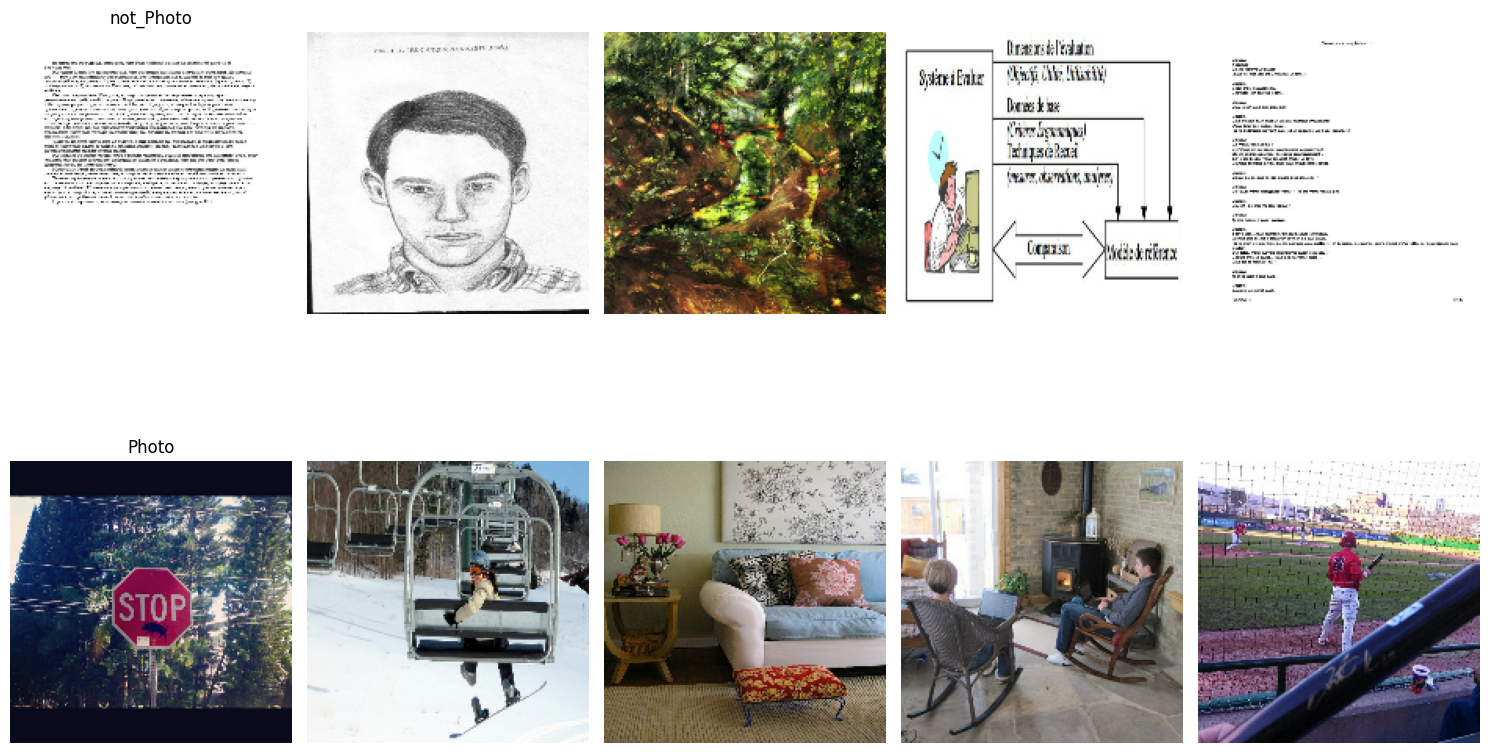

--Computing class distribution--


2025-04-12 15:03:16.757974: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


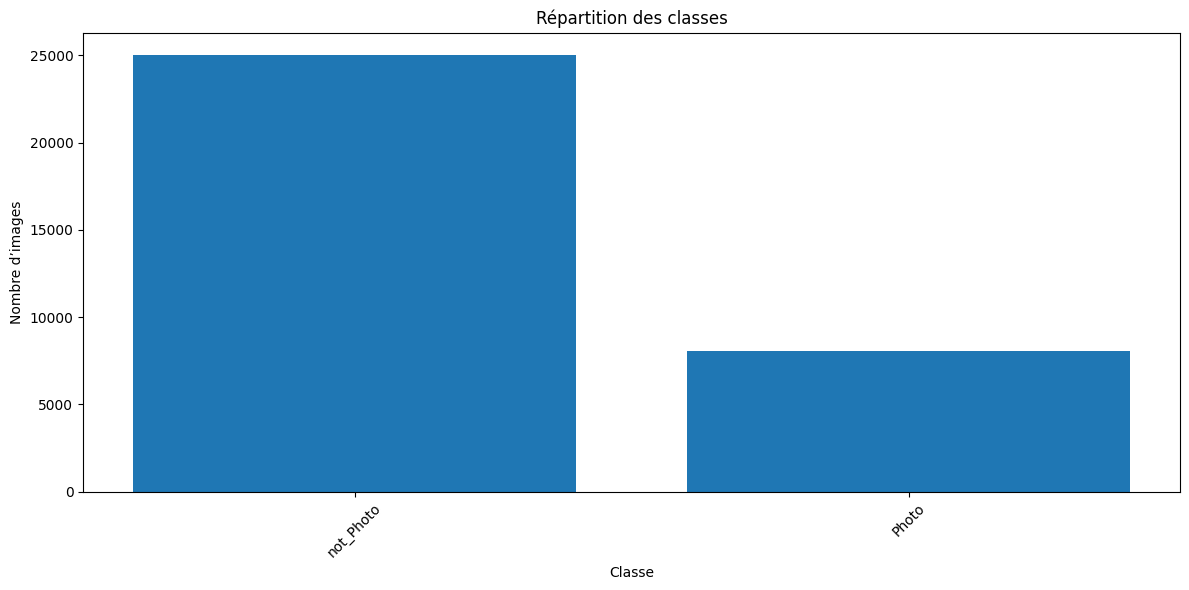

In [15]:
## DATA VISUALIZATION WORKFLOW
if data_visualization:
    # 1. Visualize class samples
    visualize_class_samples(dataset=train_ds, class_names=class_names, samples_per_class=5)

    # 2. Visualize class distribution
    visualize_class_distribution(dataset=train_ds, class_names=class_names)

In [16]:
## CALLBACK FUNCTIONS
class ConfusionMatrixCallback(tf.keras.callbacks.Callback):
    """
    Confusion matrix callback.
    """
    def __init__(self, val_data, class_names):
        super().__init__()
        self.val_data = val_data
        self.class_names = class_names

    def on_epoch_end(self, epoch, logs=None):
        y_true, y_pred = [], []

        for images, labels in self.val_data:
            preds = self.model.predict(images, verbose=0)
            y_true.extend(labels.numpy())
            if preds.shape[-1] == 1:  # Binary
                y_pred.extend((preds > 0.5).astype(int).flatten())
            else:  # Multiclass
                y_pred.extend(np.argmax(preds, axis=1))

        self.log_confusion_table(y_true, y_pred)

        cm = confusion_matrix(y_true, y_pred)
        fig, ax = plt.subplots(figsize=(6, 6))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=self.class_names)
        disp.plot(ax=ax, xticks_rotation=45)
        plt.title(f"Confusion Matrix - Epoch {epoch + 1}")
        plt.tight_layout()
        wandb.log({f"conf_mat_img_epoch_{epoch + 1}": wandb.Image(fig)})
        plt.close(fig)

    def log_confusion_table(self, y_true, y_pred):
        table = wandb.Table(columns=["Actual", "Predicted", "nPredictions"])
        counts = Counter(zip(y_true, y_pred))
        for (true, pred), count in counts.items():
            table.add_data(self.class_names[true], self.class_names[pred], count)
        wandb.log({"conf_mat_table": table})

# Callback creation
def create_callbacks(model_name="default_model", tensorboard=True, early_stopping=True, model_checkpoint=True, conf_matrix=False, val_data=None, class_names=None):
    """
    Create a list of callbacks for model training.
    Parameters:
    - model_name: Name of the model
    - tensorboard: If True, adds TensorBoard callback
    - early_stopping: If True, adds EarlyStopping callback
    - model_checkpoint: If True, adds ModelCheckpoint callback
    - conf_matrix: If True, adds ConfusionMatrixCallback
    - val_data: Validation data for ConfusionMatrixCallback
    - class_names: Class names for ConfusionMatrixCallback
    Returns:
    - List of callbacks
    """
    log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
    callbacks = []

    if tensorboard:
        tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
        callbacks.append(tensorboard_callback)

    if early_stopping:
        early_stopping_callback = tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=4,
            restore_best_weights=True
        )
        callbacks.append(early_stopping_callback)

    if model_checkpoint:
        checkpoint_dir = "checkpoints"
        os.makedirs(checkpoint_dir, exist_ok=True)
        timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
        model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
            filepath=os.path.join(checkpoint_dir, f"{model_name}{timestamp}.keras"),
            monitor='val_loss',
            save_best_only=True,
            verbose=0
        )
        callbacks.append(model_checkpoint_callback)

    if conf_matrix and val_data is not None and class_names is not None:
        cm_callback = ConfusionMatrixCallback(val_data=val_data, class_names=class_names)
        callbacks.append(cm_callback)

    return callbacks

In [17]:
## MODELS PREPARATION FUNCTIONS
# Model creation
def create_model(model_name, input_shape=(img_height, img_width, 3), num_classes=len(class_names), train_transfer_model=False, transfer_learning=False, target_binary_class_name=None):
    """
    Creates an image classification model with customizable architecture.
    Parameters:
    - model_name (str): Name of the model to create
    - input_shape (tuple): Dimensions of input images (height, width, channels)
    - num_classes (int): Number of classes for classification
    - train_transfer_model (bool): If True, pre-trained model layers will be trainable
    - transfer_learning (bool): If True, uses VGG16 pre-trained model as base
    Returns:
    - Model ready for training
    """
    print(f"--Creating model: {model_name}--")

    data_augmentation = tf.keras.Sequential([
        tf.keras.layers.RandomRotation(0.2),
        tf.keras.layers.RandomZoom(0.2),
        tf.keras.layers.RandomTranslation(0.1, 0.1),
        tf.keras.layers.RandomContrast(0.2),
        tf.keras.layers.RandomBrightness(factor=0.2)
    ])

    inputs = tf.keras.Input(shape=input_shape)

    x = data_augmentation(inputs, training=True)

    if transfer_learning:
        base_model = VGG16(
            input_shape=input_shape,
            include_top=False,
            weights='imagenet'
        )
        base_model.trainable = train_transfer_model

        x = base_model(x, training=False)
        x = tf.keras.layers.GlobalAveragePooling2D()(x)
        x = tf.keras.layers.Dense(128, activation='relu')(x)


    else:
        x = tf.keras.layers.Rescaling(1./255)(x)
        x = tf.keras.layers.Conv2D(32, (3, 3), activation='relu')(x)
        x = tf.keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
        x = tf.keras.layers.Conv2D(64, (3, 3), activation='relu')(x)
        x = tf.keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
        x = tf.keras.layers.Flatten()(x)
        x = tf.keras.layers.Dropout(0.3)(x)
        x = tf.keras.layers.Dense(128, activation='relu')(x)

    if target_binary_class_name:
        outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    else:
        outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs, outputs, name=model_name)

    return model

# Model compilation
def check_and_compile_model(model, model_name, target_binary_class_name):
    """
    Check if the model is compiled, compile it with default settings if not.
    Parameters:
    - model: The model to check
    - model_name: Name of the model (for logging)
    Returns:
    - The (possibly compiled) model
    """
    print(f"Compiling {model_name}...")
    if target_binary_class_name:
        loss = "binary_crossentropy"
        print(f"Using binary classification loss: {loss}")
    else:
        loss = "sparse_categorical_crossentropy"
        print(f"Using classification loss: {loss}")

    model.compile(
        optimizer='adam',
        loss=loss,
        metrics=['accuracy']
    )

    return model

# Model training
def train_model(model, model_name, train_ds, val_ds, epochs=10, save_path=None, class_weight=False, target_binary_class_name=None, callbacks=None):
    """
    Train a single model and optionally save it.
    Parameters:
    - model: The model object to train
    - model_name: Name of the model (for logging and saving)
    - train_ds: Training dataset
    - val_ds: Validation dataset
    - epochs: Number of epochs to train the model
    - save_path: Path to save the trained model (if None, model won't be saved)
    Returns:
    - The trained model
    """
    print(f"\n--Training {model_name}--")

    model = check_and_compile_model(model, model_name, target_binary_class_name)
    if (class_weight):
        model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=epochs,
            verbose=2,
            callbacks=callbacks,
            class_weight = add_class_weights()
        )

    else :
        model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=epochs,
            callbacks=callbacks,
            verbose=2
        )

    if save_path:
        os.makedirs(save_path, exist_ok=True)
        model_save_path = os.path.join(save_path, f"{model_name}.keras")
        model.save(model_save_path)
        print(f"Model saved to {model_save_path}")
        
        artifact = wandb.Artifact(name=f"{model_name}_model", type="model")
        artifact.add_file(model_save_path)
        wandb.log_artifact(artifact)
    return model

# Class weights
def add_class_weights():
    """
    Compute class weights for imbalanced datasets.
    Returns:
    - class_weights_dict: Dictionary mapping class indices to weights
    """
    y_train = []

    for _, labels in train_ds:
        y_train.extend(labels.numpy())

    class_weights = compute_class_weight(
        class_weight="balanced",
        classes=np.unique(y_train),
        y=y_train
    )
    class_weights_dict = dict(enumerate(class_weights))
    print("Class weights :", class_weights_dict)
    return class_weights_dict

In [ ]:
## MODELS WORKFLOW
# 1. Create model
model = create_model(
    model_name=model_name,
    input_shape=(img_height, img_width, 3),
    num_classes=len(class_names),
    train_transfer_model=train_transfer_model,
    transfer_learning=transfer_learning,
    target_binary_class_name=target_binary_class_name
)



# 2. Initialize callbacks
run = wandb.init(
    entity="tom-antoine-cesi",
    project="Leyanda",
    name=f"{model_name}_{datetime.datetime.now().strftime('%Y%m%d-%H%M%S')}",
    reinit=True,
    config={
        "model": model_name,
        "learning_rate": learning_rate,
        "epochs": epochs,
        "binary": target_binary_class_name,
    }
)
callback = [WandbMetricsLogger()] + create_callbacks(
    model_name=model_name,
    tensorboard=True,
    early_stopping=True,
    model_checkpoint=True,
    conf_matrix=True,
    val_data=test_ds,
    class_names=class_names
)

# 2. Train model
train_model(
    model=model,
    model_name=model_name,
    train_ds=train_ds,
    val_ds=val_ds,
    epochs=epochs,
    save_path=save_path,
    class_weight=class_weight,
    target_binary_class_name=target_binary_class_name,
    callbacks=callback
)

print(f"Run summary : {run.summary}")
run.finish()

--Creating model: Leyanda_CNN_bin_Photo_transfer_e10_b64_class_weight_fine_tuning--
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


wandb: Currently logged in as: epiktoo (epiktoo-cesi) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.



--Training Leyanda_CNN_bin_Photo_transfer_e10_b64_class_weight_fine_tuning--
Compiling Leyanda_CNN_bin_Photo_transfer_e10_b64_class_weight_fine_tuning...
Using binary classification loss: binary_crossentropy
Class weights : {0: 0.6602019234606329, 1: 2.060530576659609}
Epoch 1/10


2025-04-12 15:03:49.397027: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8906
W0000 00:00:1744470229.669880     129 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1744470229.742521     129 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1744470229.746567     129 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1744470229.750598     129 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1744470229.765277     129 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1744470229.771335     129 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1744470229.777487     129 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1744470229.804264     129 gpu_t

2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

...

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
2/2 ━━━━━━━━

Corrupt JPEG data: 419 extraneous bytes before marker 0xd9


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


Corrupt JPEG data: 419 extraneous bytes before marker 0xd9


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
2/2 ━━━━━━━━

Forme d'entrée attendue par le modèle : (None, 180, 180, 3)


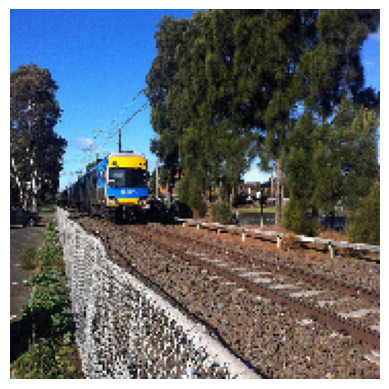

Forme de l'image avant prédiction : (1, 180, 180, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Prédictions brutes : [[8.6984515e-02 9.1301548e-01 4.4858144e-08 9.2120064e-26 2.0046141e-21]]
Classe prédite : Painting


In [ ]:
## TRAINING RESULTS AND EVALUATION FUNCTION
img_path = '../Dataset/Photo/photo_0001.jpg'

print("Model input shape:", model.input_shape)

img = image.load_img(img_path, target_size=(180, 180))
plt.imshow(img)
plt.axis('off')
plt.show()

img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
print("Image shape before prediction:", img_array.shape)


# Prédiction
predictions = model.predict(img_array)
print("Raw prediction:", predictions)

# Binary model
predicted_class_index = int(predictions[0][0] > 0.5)
predicted_class_name = class_names[predicted_class_index]
print(f"Predicted class: {predicted_class_name}")